In [105]:
from ergochemics.mapping import get_reaction_center, rc_to_nest, operator_map_reaction
from ergochemics.draw import draw_molecule, draw_reaction
from ergochemics.standardize import standardize_reaction, hash_reaction
from cgr.rule_writing import extract_reaction_template
from hydra import initialize, compose
import polars as pl
from rdkit import Chem
from rdkit.Chem import AllChem
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import SVG
import re

In [2]:
with initialize(config_path="../configs/filepaths", version_base=None):
    fps = compose(config_name="filepaths")

In [38]:
def rm_rxn_aam(smarts: str) -> str:
    """Remove atom mapping from reaction SMARTS."""
    return re.sub(r":\d+", "", smarts)

In [12]:
rxnmaps = pl.read_parquet( Path(fps.mappings) / "mapped_known_reactions_stereo_x_rxnmapper.parquet").with_columns(
    pl.col("am_smarts").map_elements(standardize_reaction, return_dtype=pl.String).alias("std_smarts")
).with_columns(
    pl.col("std_smarts").map_elements(hash_reaction, return_dtype=pl.String).alias("std_id"),
)
minmaps = pl.read_parquet( Path(fps.mappings) / "mapped_known_reactions_x_rc_plus_0_rules.parquet").with_columns(
    pl.col("template_aidxs").map_elements(rc_to_nest, return_dtype=pl.List(pl.List(pl.List(pl.Int32))))
)

[11:59:40] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:59:40] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:59:40] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:59:40] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:59:40] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:59:40] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:59:40] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:59:40] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:59:40] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:59:40] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:59:40] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:59:40] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:59:40] WARNING: not removing hydrogen atom with dummy atom neighbors
[11:59:40] WARNING: not removing hydrogen atom with

In [39]:
rxnmaps = rxnmaps.with_columns(
    pl.col("std_smarts").map_elements(rm_rxn_aam, return_dtype=pl.String).alias("std_smarts_no_aam")
).with_columns(
    pl.col("std_smarts_no_aam").map_elements(hash_reaction, return_dtype=pl.String).alias("std_id")
)

In [40]:
rxnmaps.head()

rxn_id,smarts,am_smarts,confidence,std_smarts,std_id,std_smarts_no_aam
str,str,str,f64,str,str,str
"""b46d8d265eab285dfb1d8bbd1ebffe…","""**.N[C@@H](CCC(=O)N[C@@H](CS)C…","""[*:1][*:22].[SH:2][CH2:3][C@H:…",0.825023,"""[*:1][*:22].[SH:2][CH2:3][CH:4…","""b1a2d6c10d26ef047f1a9acb2beb71…","""[*][*].[SH][CH2][CH]([NH][C](=…"
"""4976cf2aff1b70ebbe8b8b9ada264f…","""*.*.*.*.*.*.*.*.*OP(=O)(O)OC[C…","""[*:68].[*:74].[*:59].[*:53].[*…",0.000023,"""[*:68].[*:74].[*:59].[*:53].[*…","""57f7ecfcec432d743f12611908e42a…","""[*].[*].[*].[*].[*].[*].[*].[*…"
"""1dc9db3c9a1d4c99bfe7a088b22a58…","""*.*.*.*.*.*.*.*.CC(C)CCC[C@@H]…","""[*:61].[*:73].[*:67].[*:55].[*…",0.000004,"""[*:61].[*:73].[*:67].[*:55].[*…","""d8a20598ee19b76df429c22e7f079b…","""[*].[*].[*].[*].[*].[*].[*].[*…"
"""da05693d33eb5058b4cdcde95982ed…","""*.*.*.*.*.C=CC1=C(C)/C(=C/c2[n…","""[*:55].[*:64].[*:61].[*:58].[*…",0.000016,"""[*:55].[*:64].[*:61].[*:58].[*…","""734a694f3445d77e244e6d29489f4a…","""[*].[*].[*].[*].[*].[CH2]=[CH]…"
"""636da05d81d76a4c046a89923092f8…","""*.*.*.*.*.C=CC1=C(C)C(=O)N/C1=…","""[*:55].[*:64].[*:58].[*:61].[*…",0.000007,"""[*:55].[*:64].[*:58].[*:61].[*…","""83f878161ad96cfc503a5e3ec5be83…","""[*].[*].[*].[*].[*].[CH2]=[CH]…"


In [14]:
test = rxnmaps.with_columns(
    pl.col("am_smarts").str.len_chars().alias("am_smarts_length")
).sort("am_smarts_length").filter(
    pl.col("am_smarts").str.contains_any(["@", "\\", "/"])
)
test.head()

rxn_id,smarts,am_smarts,confidence,std_smarts,std_id,am_smarts_length
str,str,str,f64,str,str,u32
"""497f5bbc89d747a644c0c82bf99298…","""*C=O.C#N>>*[C@H](O)C#N""","""[*:1][CH:2]=[O:3].[CH:4]#[N:5]…",0.999994,"""[*:1][CH:2]=[O:3].[CH:4]#[N:5]…","""563e977d424b967ac4a23fd7d5d7a8…",63
"""a8f69af31cb9f3d466471176e019b8…","""*[C@H](O)C#N>>*C=O.C#N""","""[*:1][C@H:2]([OH:3])[C:4]#[N:5…",0.999977,"""[*:1][CH:2]([OH:3])[C:4]#[N:5]…","""074342244454f6935138547c222b24…",63
"""0604697878d6a9a7fa6d3f3f0fff07…","""*/C=C/SO>>*CC=[S+]O""","""[*:1]/[CH:2]=[CH:3]/[S:4][OH:5…",0.99195,"""[*:1][CH:2]=[CH:3][S:4][OH:5]>…","""1bf21922caad4e6573369796b74037…",64
"""1d37a3f31053e2cd946debe7560ace…","""*CC=[S+]O>>*/C=C/SO""","""[*:1][CH2:2][CH:3]=[S+:4][OH:5…",0.999758,"""[*:1][CH2:2][CH:3]=[S+:4][OH:5…","""629a4232c38b600096ff804090666a…",64
"""6e7c9995010ee422119570e5846bc0…","""C/C=C/SO>>CCC=[S+]O""","""[CH3:1]/[CH:2]=[CH:3]/[S:4][OH…",0.972457,"""[CH3:1][CH:2]=[CH:3][S:4][OH:5…","""fd727339f53c402b89e40e051012ea…",68


This shows that in general, removing stereochemistry does not alter the atom indexing in reactions.

In [41]:
def check_cross_stereo_mapping(stereo_smarts: str, smarts: str) -> bool:
    def _check_side(stereo_side: str, side: str) -> bool:
        stereo_side_mol = Chem.MolFromSmarts(stereo_side)
        side_mol = Chem.MolFromSmarts(side)
        if stereo_side_mol.GetNumAtoms() != side_mol.GetNumAtoms():
            return False
        for at in side_mol.GetAtoms():
            idx = at.GetIdx()
            stereo_at = stereo_side_mol.GetAtomWithIdx(idx)
            if at.GetSymbol() != stereo_at.GetSymbol():
                return False
            if at.GetAtomMapNum() != stereo_at.GetAtomMapNum():
                return False
        return True
    stereo_sides = stereo_smarts.split(">>")
    sides = smarts.split(">>")
    for stereo_side, side in zip(stereo_sides, sides):
        if not _check_side(stereo_side, side):
            return False
        
    return True

In [42]:
issues = []
for row in rxnmaps.iter_rows(named=True):
    if not check_cross_stereo_mapping(row['std_smarts'], row['am_smarts']):
        issues.append(row)

issues_df = pl.DataFrame(issues)
print(f"Found {len(issues)} issues with cross-stereo mapping.")
issues_df.head()

Found 68 issues with cross-stereo mapping.


rxn_id,smarts,am_smarts,confidence,std_smarts,std_id,std_smarts_no_aam
str,str,str,f64,str,str,str
"""6ac97f0cedbb90aae216cd95c8b4f0…","""*C1=C(*)c2cc3[nH]c4c(c3C)C(=O)…","""[*:1][C:2]1=[C:3]([*:4])[c:5]2…",0.317818,"""O[C:40]([CH2:39][CH2:38][CH:37…","""74f0e03420f751173db40d6b2954d9…","""O[C]([CH2][CH2][CH]1[c]2[c]3[c…"
"""8aa5f20267fab7d0c42effe7eaee59…","""*C1=C(*)c2cc3[nH]c4c(c3C)C(=O)…","""[*:1][C:2]1=[C:3]([*:4])[c:5]2…",0.670495,"""[*:1][C:2]1=[C:3]([*:4])[c:5]2…","""5e3400ce018e37ee2ded5f49dc20ce…","""[*][C]1=[C]([*])[c]2[cH][c]3[n…"
"""d732dcf48da4a80dc1cca26c05c543…","""C/C(=C\CO)CCC[C@H](C)CCC[C@H](…","""[CH2:43](/[CH:44]=[C:45](\[CH3…",0.671719,"""[CH2:43]([CH:44]=[C:45]([CH3:4…","""78bb8e9aa31f5c6da6b46eb81978bc…","""[CH2]([CH]=[C]([CH3])[CH2][CH2…"
"""8b88a2b8026d4eb930de27860d3f79…","""C/C(=C\COP(=O)(O)OP(=O)(O)O)CC…","""[CH2:43](/[CH:44]=[C:45](\[CH3…",0.119506,"""[CH2:43]([CH:44]=[C:45]([CH3:4…","""4c74236f719d1b1e1963361f269b71…","""[CH2]([CH]=[C]([CH3])[CH2][CH2…"
"""8550afe8d42204eb66b820c971d728…","""C=CC1=C(C)/C(=C/C2=N/C(=C3\c4[…","""[CH2:1]=[CH:2][C:3]1=[C:4]([CH…",0.719638,"""O[C:39]([CH2:38][CH2:37][CH:36…","""3602b8678b81d1ad7c667b0fc717eb…","""O[C]([CH2][CH2][CH]1[C](=[C]2[…"


This 

In [102]:
def check_elemental_symbol_correspondence(am_smarts: str, smarts: str) -> bool:
    def _check_side(am_side: str, side: str) -> bool:
        am_side_mol = Chem.MolFromSmarts(am_side)
        side_mol = Chem.MolFromSmarts(side)
        if am_side_mol.GetNumAtoms() != side_mol.GetNumAtoms():
            return False
        for at in side_mol.GetAtoms():
            idx = at.GetIdx()
            am_at = am_side_mol.GetAtomWithIdx(idx)
            if at.GetSymbol() != am_at.GetSymbol():
                print(f"Elemental symbol mismatch at atom index {idx}: {at.GetSymbol()} vs {am_at.GetSymbol()}")
                print(f"AM: {am_at.GetAtomMapNum()}")
                return False
        return True
    
    def _split_and_sort(smarts: str) -> list[str]:
        lhs, rhs = [side.split(".") for side in smarts.split(">>")]
        ct_atoms = lambda mol: mol.GetNumAtoms()
        lhs = sorted([Chem.MolFromSmiles(smi) for smi in lhs], key=ct_atoms)
        rhs = sorted([Chem.MolFromSmiles(smi) for smi in rhs], key=ct_atoms)
        lhs = ".".join(Chem.MolToSmiles(mol, ignoreAtomMapNumbers=True) for mol in lhs)
        rhs = ".".join(Chem.MolToSmiles(mol, ignoreAtomMapNumbers=True) for mol in rhs)
        return [lhs, rhs]
    am_sides = _split_and_sort(am_smarts)
    sides = _split_and_sort(smarts)
    i = 0
    for am_side, side in zip(am_sides, sides):
        print(f"Checking side {i}...")
        if not _check_side(am_side, side):
            return False
        
        i += 1
        
    return True

In [62]:
krs_stereo = pl.read_parquet(
    Path(fps.known) / "known_reactions_stereo.parquet"
).with_columns(
    pl.col("smarts").map_elements(standardize_reaction, return_dtype=pl.String).alias("stereo_free_smarts")
).with_columns(
    pl.col("stereo_free_smarts").map_elements(hash_reaction, return_dtype=pl.String).alias("stereo_free_id")
)
krs_stereo.head()

[12:45:14] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:45:14] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:45:14] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:45:14] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:45:14] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:45:14] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:45:14] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:45:14] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:45:14] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:45:14] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:45:14] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:45:14] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:45:14] WARNING: not removing hydrogen atom with dummy atom neighbors
[12:45:14] WARNING: not removing hydrogen atom with

id,smarts,enzymes,reverse,db_ids,stereo_free_smarts,stereo_free_id
str,str,list[str],str,list[str],str,str
"""b46d8d265eab285dfb1d8bbd1ebffe…","""**.N[C@@H](CCC(=O)N[C@@H](CS)C…","[""Q9JHF7"", ""Q10CE7"", … ""Q9C6C8""]","""8432125869115d452c561dd1e25f63…","[""RHEA:16438""]","""**.NC(CCC(=O)NC(CS)C(=O)NCC(=O…","""e908a824c912d1e39c46de92d1f738…"
"""535c6a2f34241db37f743f22a5e95c…","""*.*.*.*.*.*.*.*.*.*.CC(C)(COP(…","[""Q0UK48"", ""A0A0C6DWS6"", … ""A0A0C6E0I7""]","""e51c025d3c18dae9041416e70dfac9…","[""RHEA:51350""]","""*.*.*.*.*.*.*.*.*.*.CC(C)(COP(…","""d86d99a8143d3be8fc861a5de5e625…"
"""a47bd87f60fa08481da36aaacef70e…","""*.*.*.*.*.*.*.*.*N[C@@H](COP(=…","[""A0A482N9V7"", ""G0REX6"", ""P0DO30""]","""83a2ccb617c9e514b6f266743d1f21…","[""RHEA:64546""]","""*.*.*.*.*.*.*.*.*NC(COP(=O)(O)…","""2972b2db66715ba6f3d6aeaf07f31b…"
"""4976cf2aff1b70ebbe8b8b9ada264f…","""*.*.*.*.*.*.*.*.*OP(=O)(O)OC[C…","[""Q57952"", ""Q2NFF7"", … ""O26377""]","""dcb9aaa495e383093b8b4441b3640a…","[""RHEA:64377""]","""*.*.*.*.*.*.*.*.*OP(=O)(O)OCC(…","""572e4a84a946af07c9ab6fd1c0347b…"
"""1dc9db3c9a1d4c99bfe7a088b22a58…","""*.*.*.*.*.*.*.*.CC(C)CCC[C@@H]…","[""Q57952"", ""Q2NFF7"", … ""O26377""]","""8de6d064aa2de352be586017ec0da8…","[""RHEA:64369""]","""*.*.*.*.*.*.*.*.CC(C)CCCC(C)CC…","""dfe7fc761de3c213bf2b18fae4f8a5…"


In [65]:
transfer_table = minmaps.select(["rxn_id", "am_smarts", "rule", "rule_id"]).join(
    other=krs_stereo.select(["id", "stereo_free_id", "stereo_free_smarts", "smarts"]),
    left_on="rxn_id",
    right_on="stereo_free_id",
    how="inner"
)

In [86]:
elt_issues = []
for row in transfer_table.iter_rows(named=True):
    if not check_elemental_symbol_correspondence(row['am_smarts'], row['smarts']):
        elt_issues.append(row)

print(f"Found {len(elt_issues)} issues with elemental symbol correspondence.")
print(f"Fraction of issues: {len(elt_issues) / transfer_table.shape[0]:.2f}")
elt_issues_df = pl.DataFrame(elt_issues)
elt_issues_df.head()

Found 2073 issues with elemental symbol correspondence.
Fraction of issues: 0.10


rxn_id,am_smarts,rule,rule_id,id,stereo_free_smarts,smarts
str,str,str,i64,str,str,str
"""af8ee91e58a9ae1390555e207b2ad6…","""[CH3:67][C:65]([CH3:68])([CH2:…","""[#16:1].[#6:2]-[#6:3]>>[#6:2].…",787,"""a4ec07527df04cbc9231536b2c16c5…","""*C(=O)CC(=O)SCCNC(=O)CCNC(=O)C…","""*C(=O)CC(=O)SCCNC(=O)CCNC(=O)[…"
"""4446caf578160e88923a1176b42221…","""[*:31][C:28](=[O:32])[NH:26][C…","""[#6:1]-[#8:2].[#8:3]>>[#6:1]-[…",517,"""4911c6dd8ecafbc1f919a22bca0bc5…","""*C(=O)NC(COC1OC(CO)C(OC2OC(CO)…","""*C(=O)N[C@@H](CO[C@@H]1O[C@H](…"
"""75fe026033a09b7775a73dc02441e2…","""[*:31][C:28](=[O:32])[NH:26][C…","""[#6:1]-[#8:2].[#8:3]>>[#6:1]-[…",517,"""fc7ee1f4a6d70d79ac86fbeab4c4c6…","""*C(=O)NC(COC1OC(CO)C(OC2OC(CO)…","""*C(=O)N[C@@H](CO[C@@H]1O[C@H](…"
"""8bb3319bbfd740ceec4edf0bd2ce42…","""[CH3:19][C:16](=[O:20])[NH:13]…","""[#6:1]-[#8:2].[#8:3]>>[#6:1]-[…",517,"""4a94c7e68dc3662053d1c5bb21d9ff…","""*C(=O)NC(COC1OC(CO)C(OC2OC(CO)…","""*C(=O)N[C@@H](CO[C@@H]1O[C@H](…"
"""29679aae42f079906c343d68963560…","""[*:31][C:28](=[O:32])[NH:26][C…","""[#6:1]-[#8:2].[#8:3]>>[#6:1]-[…",517,"""0b97134173026b783e6cf23603c3f9…","""*C(=O)NC(COC1OC(CO)C(OC2OC(CO)…","""*C(=O)N[C@@H](CO[C@@H]1O[C@H](…"


In [96]:
test = elt_issues_df.row(1, named=True)
test

{'rxn_id': '4446caf578160e88923a1176b42221f99fc171b2',
 'am_smarts': '[*:31][C:28](=[O:32])[NH:26][CH:25]([CH2:24][O:23][CH:20]1[O:16][CH:14]([CH2:17][OH:21])[CH:13]([O:12][CH:9]2[O:5][CH:3]([CH2:6][OH:10])[CH:1]([OH:47])[CH:4]([OH:7])[CH:8]2[OH:11])[CH:15]([OH:18])[CH:19]1[OH:22])[CH:27]([*:29])[OH:30].[CH3:43][C:39](=[O:44])[NH:36][CH:34]1[CH:33]([OH:2])[O:35][CH:38]([CH2:42][OH:46])[CH:40]([OH:45])[CH:37]1[OH:41]>>[*:31][C:28](=[O:32])[NH:26][CH:25]([CH2:24][O:23][CH:20]1[O:16][CH:14]([CH2:17][OH:21])[CH:13]([O:12][CH:9]2[O:5][CH:3]([CH2:6][OH:10])[CH:1]([O:2][CH:33]3[O:35][CH:38]([CH2:42][OH:46])[CH:40]([OH:45])[CH:37]([OH:41])[CH:34]3[NH:36][C:39]([CH3:43])=[O:44])[CH:4]([OH:7])[CH:8]2[OH:11])[CH:15]([OH:18])[CH:19]1[OH:22])[CH:27]([*:29])[OH:30].[OH2:47]',
 'rule': '[#6:1]-[#8:2].[#8:3]>>[#6:1]-[#8:3].[#8:2]',
 'rule_id': 517,
 'id': '4911c6dd8ecafbc1f919a22bca0bc5b41fc78e48',
 'stereo_free_smarts': '*C(=O)NC(COC1OC(CO)C(OC2OC(CO)C(O)C(O)C2O)C(O)C1O)C(*)O.CC(=O)NC1C(O)OC(CO)C(O)C

In [103]:
def _split_and_sort(smarts: str) -> list[str]:
        lhs, rhs = [side.split(".") for side in smarts.split(">>")]
        ct_atoms = lambda mol: mol.GetNumAtoms()
        lhs = sorted([Chem.MolFromSmiles(smi) for smi in lhs], key=ct_atoms)
        rhs = sorted([Chem.MolFromSmiles(smi) for smi in rhs], key=ct_atoms)
        lhs = ".".join(Chem.MolToSmiles(mol, ignoreAtomMapNumbers=True) for mol in lhs)
        rhs = ".".join(Chem.MolToSmiles(mol, ignoreAtomMapNumbers=True) for mol in rhs)
        return [lhs, rhs]

print(_split_and_sort(test['am_smarts']))
print(_split_and_sort(test['smarts']))

['[CH3:43][C:39](=[O:44])[NH:36][CH:34]1[CH:33]([OH:2])[O:35][CH:38]([CH2:42][OH:46])[CH:40]([OH:45])[CH:37]1[OH:41].[*:31][C:28](=[O:32])[NH:26][CH:25]([CH2:24][O:23][CH:20]1[O:16][CH:14]([CH2:17][OH:21])[CH:13]([O:12][CH:9]2[O:5][CH:3]([CH2:6][OH:10])[CH:1]([OH:47])[CH:4]([OH:7])[CH:8]2[OH:11])[CH:15]([OH:18])[CH:19]1[OH:22])[CH:27]([*:29])[OH:30]', '[OH2:47].[*:31][C:28](=[O:32])[NH:26][CH:25]([CH2:24][O:23][CH:20]1[O:16][CH:14]([CH2:17][OH:21])[CH:13]([O:12][CH:9]2[O:5][CH:3]([CH2:6][OH:10])[CH:1]([O:2][CH:33]3[O:35][CH:38]([CH2:42][OH:46])[CH:40]([OH:45])[CH:37]([OH:41])[CH:34]3[NH:36][C:39]([CH3:43])=[O:44])[CH:4]([OH:7])[CH:8]2[OH:11])[CH:15]([OH:18])[CH:19]1[OH:22])[CH:27]([*:29])[OH:30]']
['CC(=O)N[C@@H]1[C@@H](O)[C@@H](O)[C@@H](CO)O[C@H]1O.*C(=O)N[C@@H](CO[C@@H]1O[C@H](CO)[C@@H](O[C@@H]2O[C@H](CO)[C@H](O)[C@H](O)[C@H]2O)[C@H](O)[C@H]1O)[C@@H](*)O', 'O.*C(=O)N[C@@H](CO[C@@H]1O[C@H](CO)[C@@H](O[C@@H]2O[C@H](CO)[C@H](O[C@@H]3O[C@H](CO)[C@H](O)[C@H](O)[C@H]3NC(C)=O)[C@H](O)[C@H]2

In [104]:
check_elemental_symbol_correspondence(test['am_smarts'], test['smarts'])

Checking side 0...
Elemental symbol mismatch at atom index 7: C vs O
AM: 35


False

In [106]:
operator_map_reaction(test['smarts'], test['rule'])

[13:28:35] Initializing MetalDisconnector
[13:28:35] Running MetalDisconnector
[13:28:35] Initializing Normalizer
[13:28:35] Running Normalizer
[13:28:35] Initializing MetalDisconnector
[13:28:35] Running MetalDisconnector
[13:28:35] Initializing Normalizer
[13:28:35] Running Normalizer
[13:28:35] Initializing MetalDisconnector
[13:28:35] Running MetalDisconnector
[13:28:35] Initializing Normalizer
[13:28:35] Running Normalizer
[13:28:35] Initializing MetalDisconnector
[13:28:35] Running MetalDisconnector
[13:28:35] Initializing Normalizer
[13:28:35] Running Normalizer


OperatorMapResult(did_map=True, aligned_smarts='*C(=O)NC(COC1OC(CO)C(OC2OC(CO)C(O)C(O)C2O)C(O)C1O)C(*)O.CC(=O)NC1C(O)OC(CO)C(O)C1O>>*C(=O)NC(COC1OC(CO)C(OC2OC(CO)C(OC3OC(CO)C(O)C(O)C3NC(C)=O)C(O)C2O)C(O)C1O)C(*)O.O', atom_mapped_smarts='[*:31][C:28](=[O:32])[NH:26][CH:25]([CH2:24][O:23][CH:20]1[O:16][CH:14]([CH2:17][OH:21])[CH:13]([O:12][CH:9]2[O:5][CH:3]([CH2:6][OH:10])[CH:1]([OH:47])[CH:4]([OH:7])[CH:8]2[OH:11])[CH:15]([OH:18])[CH:19]1[OH:22])[CH:27]([*:29])[OH:30].[CH3:43][C:39](=[O:44])[NH:36][CH:34]1[CH:33]([OH:2])[O:35][CH:38]([CH2:42][OH:46])[CH:40]([OH:45])[CH:37]1[OH:41]>>[*:31][C:28](=[O:32])[NH:26][CH:25]([CH2:24][O:23][CH:20]1[O:16][CH:14]([CH2:17][OH:21])[CH:13]([O:12][CH:9]2[O:5][CH:3]([CH2:6][OH:10])[CH:1]([O:2][CH:33]3[O:35][CH:38]([CH2:42][OH:46])[CH:40]([OH:45])[CH:37]([OH:41])[CH:34]3[NH:36][C:39]([CH3:43])=[O:44])[CH:4]([OH:7])[CH:8]2[OH:11])[CH:15]([OH:18])[CH:19]1[OH:22])[CH:27]([*:29])[OH:30].[OH2:47]', template_aidxs=(((19, 20), (6,)), ((19, 20), (0,))))

In [ ]:
i = 0

In [ ]:

test_sma = test.row(i, named=True)['am_smarts']
print(test_sma)
print(standardize_reaction(test_sma))
i += 1

[*:1][CH2:2][CH:3]=[S+:4][OH:5]>>[*:1]/[CH:2]=[CH:3]/[S:4][OH:5]
[*:1][CH2:2][CH:3]=[S+:4][OH:5]>>[*:1][CH:2]=[CH:3][S:4][OH:5]


In [ ]:
standardize_reaction("[OH2:2].[OH2:1]>>[O:1]=[O:2]")

'[OH2:2].[OH2:1]>>[O:1]=[O:2]'

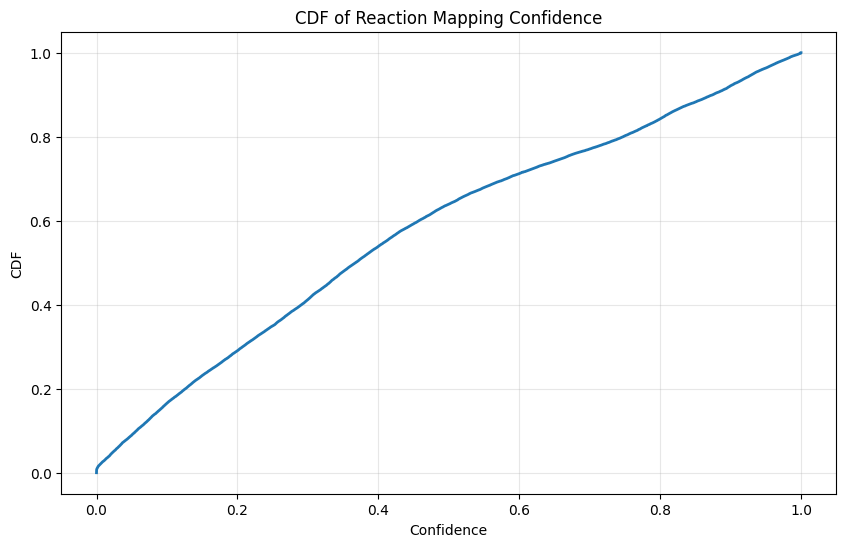

In [ ]:
# Extract confidence values and sort them
confidence = rxnmaps['confidence'].to_numpy()
confidence_sorted = np.sort(confidence)

# Calculate CDF
cdf = np.arange(1, len(confidence_sorted) + 1) / len(confidence_sorted)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(confidence_sorted, cdf, linewidth=2)
plt.xlabel('Confidence')
plt.ylabel('CDF')
plt.title('CDF of Reaction Mapping Confidence')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
minmaps.head()

rxn_id,smarts,am_smarts,rule,template_aidxs,rule_id
str,str,str,str,list[list[list[i32]]],i64
"""4fc554b86bb64504ce3bb78f4c02ac…","""*C#N.O>>*C(N)=O""","""[*:4][C:2]#[N:1].[OH2:3]>>[*:4…","""[#6:1]#[#7:2].[#8:3]>>[#7:2]-[…","[[[1, 2], [0]], [[1, 2, 3]]]",549
"""4fe435c487c7b2dc720dff02a9af2d…","""*C#N.O>>*C=NO""","""[*:4][C:1]#[N:2].[OH2:3]>>[*:4…","""[#6:1]#[#7:2].[#8:3]>>[#6:1]=[…","[[[1, 2], [0]], [[1, 2, 3]]]",785
"""db3a4d53e3f2557babac4615ca5518…","""*C(*)S.*C(*)S.O=O>>*C(*)SSC(*)…","""[*:4][CH:3]([*:5])[SH:1].[*:7]…","""[#16:1].[#16:2].[#8:3]=[#8:4]>…","[[[3], [3], [0, 1]], [[3, 4], [0, 1]]]",747
"""74aa76da460568ccddd08f17f78cd8…","""*C(*)SSC(*)*.OO>>*C(*)S.*C(*)S…","""[*:3][CH:2]([*:4])[S:1][S:5][C…","""[#16:1]-[#16:2].[#8:3]-[#8:4]>…","[[[3, 4], [0, 1]], [[3], [3], [0, 1]]]",225
"""40c96410b09d3b0ef8fb9420f28029…","""*C(=Cc1c(*)c(*)c(*)c(*)c1*)C(=…","""[*:16][C:1](=[CH:2][c:17]1[c:1…","""([#8:1].[#6:2]=[#6:3])>>[#6:2]…","[[[26, 1, 2]], [[7, 8, 21]]]",412


In [ ]:
stereo_rules = pl.read_csv(
    Path(fps.rules) / "mechinferred_dt_956_rules_all_data_stereo.csv",
    separator=','
)
print(stereo_rules.height)
print(stereo_rules.unique("smarts").height)
stereo_rules.head()

15854
15854


id,smarts,confidence
i64,str,f64
0,"""[*:1]-[*:2].([C&D2&v4&H2&+0&!R…",0.825023
1,"""[*:1].[#1:2]-[#1:3]>>[#1:2]-[*…",0.763456
2,"""([O&D1&v2&H1&+0&!R:1].[c&D3&v4…",0.262201
3,"""[*:1]/[C&D3&v4&H0&+0&!R&z3:2](…",0.583276
4,"""[*:1]/[C&D3&v4&H0&+0&!R&z3:2](…",0.547656


In [ ]:
i = 0

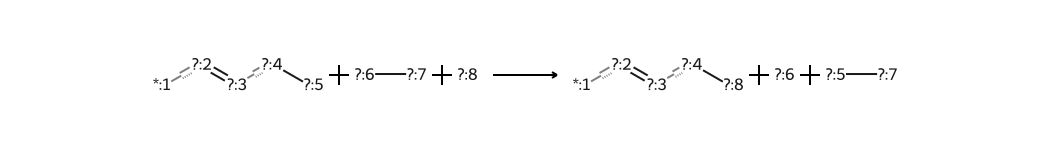

In [ ]:
row = stereo_rules.row(i, named=True)
rule = AllChem.ReactionFromSmarts(row['smarts'])
display(rule)
i+=1

Focus on decarbs

In [ ]:
rc0_decarb_id = 1009
decarb_min_maps = minmaps.filter(
    pl.col("rule_id") == rc0_decarb_id
)
decarb_ids = decarb_min_maps['rxn_id'].to_list()
decarb_rxnmaps = rxnmaps.filter(
    pl.col("std_id").is_in(decarb_ids)
)